# Simple portfolio optimization: training, validation, testing

A CRRA investor with risk aversion $\gamma$ chooses the fraction $f$ of wealth to place in a single risky asset. End-of-period wealth (per dollar) is $1 + f\,m_t$ where $m_t = (r^{\text{Mkt}}_t - r^f_t)/(1 + r^f_t)$ is the risk-adjusted return, so the one-period problem is

$$
f^\star(\gamma) \;=\; \arg\max_{f} \; \mathbb{E}\bigl[u_\gamma(1 + f\,m)\bigr], \qquad u_\gamma(x) = \begin{cases} \log x & \gamma = 1 \\ \dfrac{x^{1-\gamma} - 1}{1-\gamma} & \gamma \neq 1 \end{cases}.
$$

This notebook parallels the training/validation/testing analysis of Section 11.8 in Myerson & Zambrano, using monthly Fama–French market data and three candidate return models (Normal, Student-$t$, Johnson $S_U$):

- **Training (fold 1, 1926-07 to 1982-12, $n = 678$).** Fit each candidate by MLE. Simulate $10^5$ draws from each fit, and compute the model-implied $f^\star(\gamma)$ for each $\gamma \in \{0.25, 0.5, 0.75, 1, 2, 3\}$.
- **Validation (fold 2, 1983-01 to 2012-12, $n = 360$).** For each $(\gamma, \text{model})$ pair, evaluate realized mean utility $\frac{1}{n_2}\sum_t u_\gamma(1 + f^\star_{\text{model}}\,m_t)$ on fold-2 returns. The winning model per $\gamma$ is the one whose $f^\star$ delivers the highest realized mean utility on data it has not seen. No scoring of the probability distributions themselves; selection is by the realized payoff of the decision the model implies.
- **Testing (fold 3, 2013-01 to 2018-12, $n = 72$).** For $\gamma = 1$ only (the log-utility / Kelly case, mirroring the chapter's headline), simulate the wealth path under the winning model's $f^\star$ on realized fold-3 returns. Starting wealth $W_0 = 100{,}000$.

**One technical refinement vs. the chapter.** For the optimizer we use the single-period $m_t$ formulation, which is algebraically correct for one-period expected utility. For the wealth-path simulations on real data we keep $r^{\text{Mkt}}_t$ and $r^f_t$ separate and use $W_{t+1} = W_t \cdot [1 + (1-f)\,r^f_t + f\,r^{\text{Mkt}}_t]$, so that the $(1-f)$ dollars earn the actual risk-free rate that prevailed that month rather than a constant. Once we are out of model-land, the fitted distributions and the $m_t$ compression no longer appear.

In [1]:
import numpy as np
import pandas as pd
import requests
from io import BytesIO
from zipfile import ZipFile
from scipy import stats
from scipy.optimize import minimize_scalar
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
rng = np.random.default_rng(607)

## Data and fold structure

Same Fama–French series and fold definitions as `1_fitting_and_selecting_one_asset.ipynb`. We keep both $m_t$ and the underlying $(r^{\text{Mkt}}_t, r^f_t)$ for each fold.

In [2]:
url = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_Factors_CSV.zip"
response = requests.get(url)
with ZipFile(BytesIO(response.content)) as zfile:
    csv_name = next(n for n in zfile.namelist() if n.lower().endswith(".csv"))
    with zfile.open(csv_name) as f:
        ff = pd.read_csv(f, skiprows=3, index_col=0)
ff = ff.apply(pd.to_numeric, errors="coerce").dropna()
ff = ff[ff.index.map(lambda s: s.isdigit() and len(s) == 6)]
ff["r_mkt"] = ff["Mkt-RF"] / 100 + ff["RF"] / 100
ff["r_f"]   = ff["RF"] / 100
ff["m"]     = (ff["r_mkt"] - ff["r_f"]) / (1 + ff["r_f"])

folds = {
    "fold1": ff.loc["192607":"198212"],
    "fold2": ff.loc["198301":"201212"],
    "fold3": ff.loc["201301":"201812"],
}
pd.Series({k: len(v) for k, v in folds.items()}, name="n_obs")

fold1    678
fold2    360
fold3     72
Name: n_obs, dtype: int64

## Training stage: fit three families on fold 1

In [3]:
fold1_m = folds["fold1"]["m"].values
families = {"Normal": stats.norm, "Student t": stats.t, "Johnson SU": stats.johnsonsu}
fits = {name: dist(*dist.fit(fold1_m)) for name, dist in families.items()}

pd.DataFrame({name: {"params": np.round(f.args + tuple(f.kwds.values()), 4)}
              for name, f in fits.items()}).T

,params
Normal,"[0.0064, 0.0587]"
Student t,"[3.4535, 0.0086, 0.0383]"
Johnson SU,"[0.2593, 1.2581, 0.0197, 0.0498]"


## Simulate $10^5$ draws from each fit

Heavy sampling so rare events that the model puts probability on get a chance to show up. Independent RNG streams per family, all spawned from the same parent seed.

In [4]:
n_simulations = 100_000
child_seeds = rng.bit_generator._seed_seq.spawn(len(fits))
draws = {name: f.rvs(size=n_simulations, random_state=np.random.default_rng(seed))
         for (name, f), seed in zip(fits.items(), child_seeds)}

pd.DataFrame({name: {"m_min": x.min(), "m_max": x.max()} for name, x in draws.items()}).T.round(3)

,m_min,m_max
Normal,-0.242,0.260
Student t,-1.819,0.965
Johnson SU,-0.614,0.502


## Optimizer: CRRA expected utility in $m_t$-formulation\n\nWe maximize $\\mathbb{E}[u_\\gamma(1 + f\\,m)]$ over $f \\in [0, f_{\\max}]$ with $f_{\\max} = 5$ — an economic leverage cap (5× equity is well beyond any realistic borrowing arrangement). For draws with $1 + f\\,m \\le 0$, the CRRA utility is genuinely $-\\infty$ (ruin), but a literal `-inf` breaks the optimizer's bracket search. We instead use a smooth floor: replace any non-positive wealth with a tiny positive value $\\epsilon = 10^{-12}$ before applying $u_\\gamma$, so ruin is finite-but-huge-negative and the mean utility is a continuous decreasing function of $f$ in the ruin region. With $10^5$ draws and unbounded-support fits, ruin draws can appear; the optimizer is then naturally pushed toward conservative $f$ — that is the whole point of heavy sampling.

In [5]:
F_MAX = 5.0
EPS = 1e-12

def neg_expected_utility(f, returns, gamma):
    w = np.maximum(1.0 + f * returns, EPS)
    u = np.log(w) if gamma == 1 else (w ** (1 - gamma) - 1) / (1 - gamma)
    return -u.mean()

def optimal_fraction(returns, gamma, f_max=F_MAX):
    res = minimize_scalar(neg_expected_utility, args=(returns, gamma),
                          bounds=(0.0, f_max), method="bounded",
                          options={"xatol": 1e-6})
    return res.x

## Training stage: $f^\star$ by model and risk aversion

In [6]:
gammas = [0.25, 0.5, 0.75, 1.0, 2.0, 3.0]
f_star = pd.DataFrame(
    {name: [optimal_fraction(x, g) for g in gammas] for name, x in draws.items()},
    index=pd.Index(gammas, name="gamma"),
).round(3)
f_star

,Normal,Student t,Johnson SU
gamma,,,
0.25,5.000,5.000,5.000
0.50,3.698,5.000,2.760
0.75,2.546,2.802,1.681
1.00,1.930,1.174,1.409
2.00,0.974,0.516,0.761
3.00,0.651,0.453,0.516


## Validation stage: evaluate the three $f^\star$ portfolios on fold-2 realized returns

For each $(\gamma, \text{model})$ pair, realized mean utility on the 360 fold-2 observations,
$\frac{1}{n_2}\sum_{t \in \text{fold 2}} u_\gamma(1 + f^\star_{\text{model}}\,m_t)$.
Higher is better. The winning model per row is bolded.

In [7]:
fold2_m = folds["fold2"]["m"].values

def realized_mean_utility(f, m, gamma):
    w = 1.0 + f * m
    if np.any(w <= 0):
        return -np.inf
    return (np.log(w) if gamma == 1 else (w ** (1 - gamma) - 1) / (1 - gamma)).mean()

val_table = pd.DataFrame(
    {name: [realized_mean_utility(f_star.loc[g, name], fold2_m, g) for g in gammas]
     for name in fits},
    index=pd.Index(gammas, name="gamma"),
)
winners = val_table.idxmax(axis=1).rename("winner")
pd.concat([val_table.round(5), winners], axis=1)

,Normal,Student t,Johnson SU,winner
gamma,,,,
0.25,-inf,-inf,-inf,Normal
0.50,0.01432,-inf,0.01240,Normal
0.75,0.00994,0.01027,0.00783,Student t
1.00,0.00756,0.00559,0.00635,Normal
2.00,0.00383,0.00254,0.00335,Normal
3.00,0.00257,0.00207,0.00226,Normal


Things to look for:

1. **The winning model can differ from the CRPS winner.** In notebook 1 Johnson $S_U$ won CRPS on fold 2 by a hair (0.02449 vs. Student-$t$ 0.02452 vs. Normal 0.02527). Decision-payoff selection here often disagrees because CRPS scores bulk fit while the portfolio decision is tail-sensitive.
2. **Ruin shows up explicitly.** At very low $\gamma$ all three models recommend $f^\star$ near the economic cap $f_{\max} = 5$, and the worst fold-2 month (October 1987, $m = -0.231$) bankrupts the portfolio at $f \gtrsim 1/0.231 \approx 4.33$. Realized mean utility is $-\infty$, which is the right answer: the recommendation is operationally unusable on this validation period.
3. **Conservative isn't always better.** Student-$t$'s fitted $df \approx 3.45$ anticipates a much heavier left tail than fold 2 actually delivered; even fold 2's worst month is *milder* than what the Student-$t$ thinks is plausible. The result is that for moderate $\gamma$, Student-$t$'s more conservative $f^\star$ leaves growth on the table relative to the Normal, even though the Normal is statistically wrong about the bulk fit. The decision-payoff selection rewards whichever model best matches the *realized* validation period — not whichever has the most economically defensible tail.\n\nFor the test stage we proceed with the **$\\gamma = 1$ winner** (the log-utility / Kelly case)."

## Test stage: wealth path of the $\gamma = 1$ winner on fold 3

Starting wealth $W_0 = 100{,}000$. Wealth evolves under the **correct** time-series equation
$W_{t+1} = W_t \cdot [1 + (1-f)\,r^f_t + f\,r^{\text{Mkt}}_t]$
with the actual realized $r^{\text{Mkt}}_t$ and $r^f_t$ for each month in fold 3. No simulation, no fitted distribution — the model has done its job (telling us what $f$ to set) and now we just watch the resulting strategy play out on data it has never seen.

In [8]:
winner_gamma1 = winners.loc[1.0]
f_test = f_star.loc[1.0, winner_gamma1]

fold3 = folds["fold3"]
r_mkt = fold3["r_mkt"].values
r_f   = fold3["r_f"].values
monthly_gross = 1.0 + (1.0 - f_test) * r_f + f_test * r_mkt

W0 = 100_000.0
wealth = W0 * np.concatenate([[1.0], np.cumprod(monthly_gross)])
dates = pd.to_datetime(["2012-12-31"] + [f"{s[:4]}-{s[4:]}-01" for s in fold3.index]) + pd.offsets.MonthEnd(0)

n_months = len(fold3)
n_years  = n_months / 12
terminal = wealth[-1]
annualized = (terminal / W0) ** (1 / n_years)
max_dd = (wealth / np.maximum.accumulate(wealth) - 1).min()

summary = pd.Series({
    "winning model (gamma=1)": winner_gamma1,
    "f*": round(f_test, 3),
    "starting wealth": f"${W0:,.0f}",
    "terminal wealth": f"${terminal:,.0f}",
    "annualized growth ratio": round(annualized, 4),
    "max drawdown": f"{max_dd:.1%}",
})
summary

winning model (gamma=1)      Normal
f*                             1.93
starting wealth            $100,000
terminal wealth            $344,331
annualized growth ratio      1.2288
max drawdown                 -27.7%
dtype: object

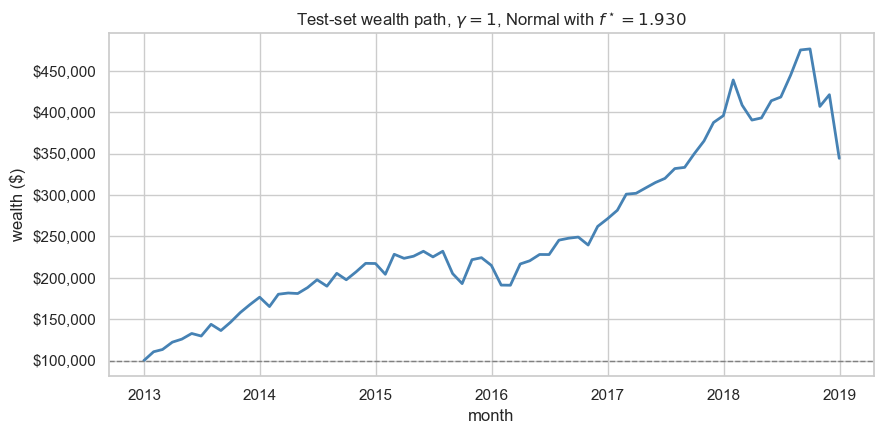

In [9]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(dates, wealth, lw=2, color="steelblue")
ax.axhline(W0, color="0.5", ls="--", lw=1)
ax.set(title=f"Test-set wealth path, $\\gamma = 1$, {winner_gamma1} with $f^\\star = {f_test:.3f}$",
       xlabel="month", ylabel="wealth ($)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
plt.show()

## Caveats for class discussion

**Winner's curse.** The test-set growth ratio reported above is the realized performance of the strategy that won the validation stage. It is an honest out-of-sample number in the sense that fold 3 was not used in either fitting or selection, but the test fold itself is small ($n = 72$ months $\approx$ 6 calendar years), so its sampling noise is appreciable. Chapter 11.8 uses a 1000-day test set; we have to live with what monthly data affords.

**No refinement after the test.** If we now look at the wealth path, think "I bet a different $\gamma$ or a different model would have looked even better," and re-run, we have spent the test set. Honest practice is to lock the report and move on; fold 4 (2019–) is reserved for a follow-up notebook.

**Borrowing rate above $r^f$.** The wealth-evolution equation uses the same $r^f_t$ for the lending leg $(1-f)\,r^f_t$ and (implicitly, when $f > 1$) for the borrowing leg. In practice retail and institutional investors face a borrowing rate strictly above $r^f$ (margin rates, repo haircuts, prime-broker spreads). The honest version uses a piecewise rate that bites when $f > 1$ and shrinks the realized return whenever the strategy is levered. This would push down both the validation-stage utility for high-$f^\star$ models and the test-set growth rate.